In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import plot, Function
from utils.problem_setup import TestProblemsSetup
from utils.utils import progress_bar, disk_cache
from utils.metrics import error_movers, error_auc_iou
from algorithms.rsvd_solvers import MatrixFreeRSVD, MatrixFreeRSVDAdjoint

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

PROBLEMS = TestProblemsSetup(n=32).get_test_problems()
SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def compute_errors(
    k: int, x: np.ndarray, x_hat: np.ndarray, x_hat_adj: np.ndarray
) -> dict[str, float]:
    return {
        'k': k,
        'rsvd_euc': np.linalg.norm(x - x_hat),
        'rsvdAdj_euc': np.linalg.norm(x - x_hat_adj),
        'rsvd_emd': error_movers(x, x_hat),
        'rsvdAdj_emd': error_movers(x, x_hat_adj),
        'rsvd_auc_iou': error_auc_iou(x, x_hat)[0],
        'rsvdAdj_auc_iou': error_auc_iou(x, x_hat_adj)[0]
    }

@disk_cache('../../results/rsvdAdjoint_error')
def experiment(k_range: np.ndarray, pid: str, lam: float = 1e-4, repeat: int = 1):
    pb = PROBLEMS[pid]

    results = []
    n_steps, step = len(k_range) * repeat, 1
    for k in k_range:
        rsvd = MatrixFreeRSVD(pb['V_h'])
        rsvd_adj = MatrixFreeRSVDAdjoint(pb['V_h'])

        for r in range(repeat):
            progress_bar(step, n_steps)
            step += 1

            # Solve via the rSVD
            rsvd.solve(k=k, seed=SEED + r)
            x_hat = rsvd.tikhonov_solve(y=pb['y'], w=rsvd.weights(), lam=lam)

            # Solve via the adjoint rSVD
            rsvd_adj.solve(k=k, seed=SEED + r)
            rsvd_adj.recover_K()
            x_hat_adj = rsvd_adj.tikhonov_solve(y=pb['y'], w=rsvd_adj.weights(), lam=lam)

            results.append(compute_errors(k, pb['x'], x_hat, x_hat_adj))
    
    return pd.DataFrame(results)



In [3]:
k_range = np.arange(5, 100)
repeat = 50
params = [
    {'k_range': k_range, 'pid': 'I',   'repeat': repeat},
    {'k_range': k_range, 'pid': 'II' , 'repeat': repeat},
    {'k_range': k_range, 'pid': 'III', 'repeat': repeat}
]
results = [{'params': p, 'df': experiment(**p)} for p in params]

########################I#########################


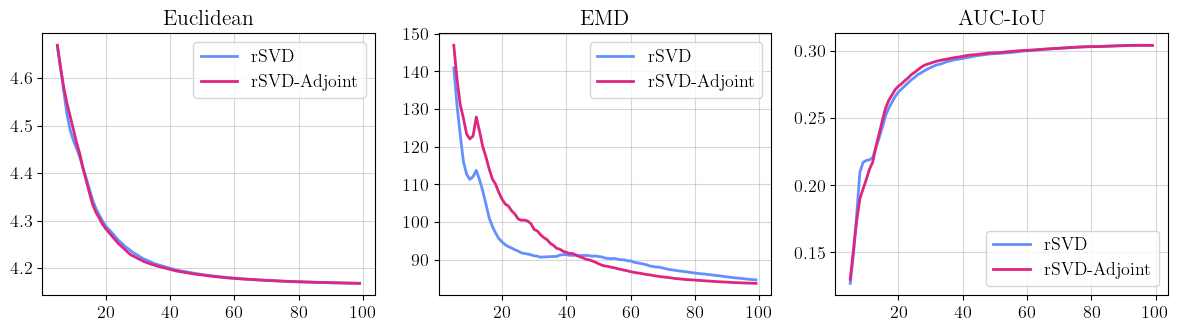

########################II########################


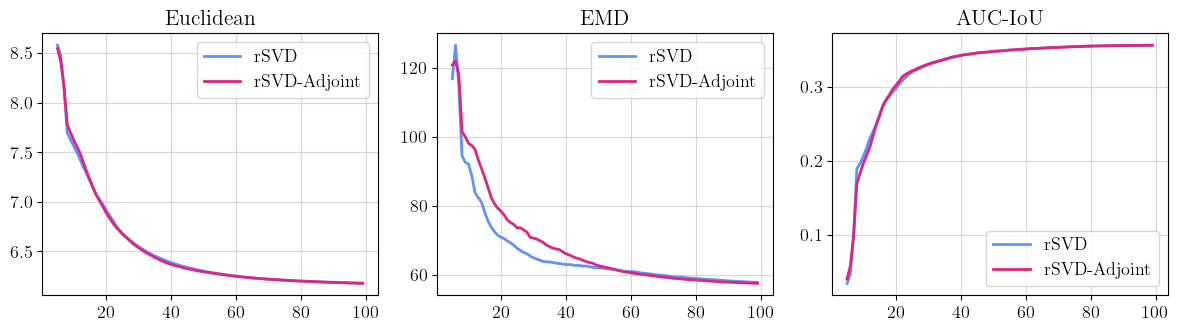

#######################III########################


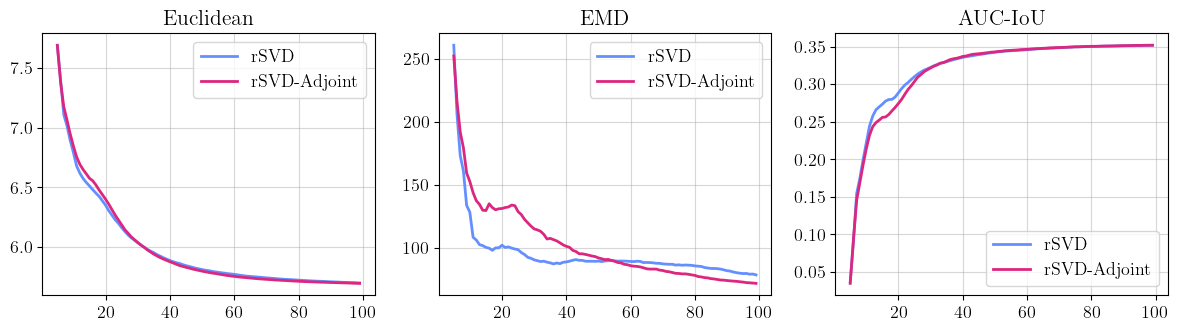

In [4]:
def plot_df(df):   
    from utils.colors import C2

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    dists = ['euc', 'emd', 'auc_iou']
    labels = ['Euclidean', 'EMD', 'AUC-IoU']
    for i, (dist, ax) in enumerate(zip(dists, axes.flat)):
        ax.set_title(labels[i])
        ax.plot(df.k, df['rsvd_' + dist], label='rSVD', c=C2[0], lw=2)
        ax.plot(df.k, df['rsvdAdj_' + dist], label='rSVD-Adjoint', c=C2[1], lw=2)

        ax.grid(True, alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()


for result in results:
    params = result['params']
    print(f"{params['pid']:#^50}")
    df = result['df'].groupby('k').agg('mean').reset_index()
    plot_df(df)


########################I#########################


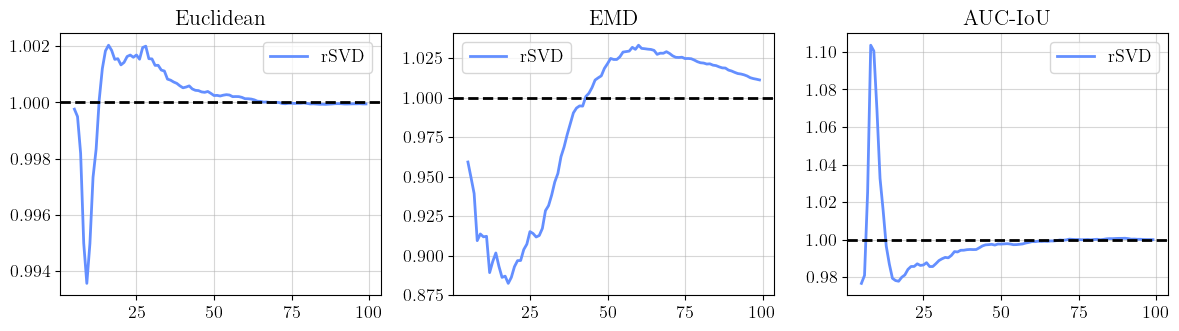

########################II########################


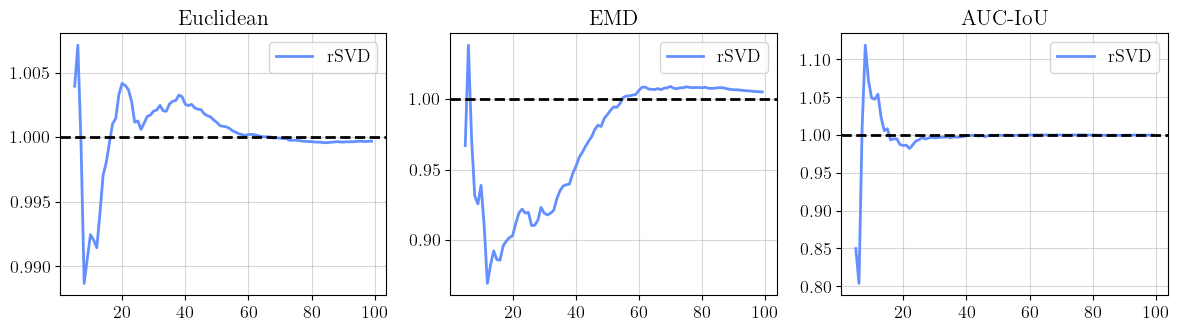

#######################III########################


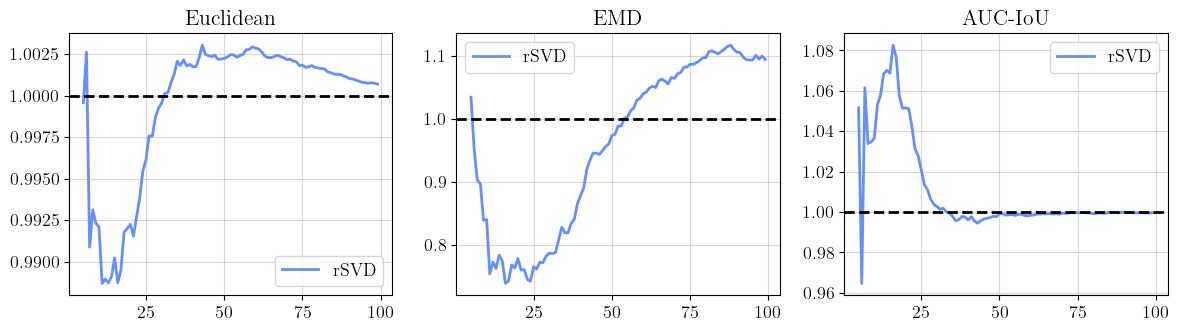

In [60]:
def plot_df_relative(df):   
    from utils.colors import C2

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    dists = ['euc', 'emd', 'auc_iou']
    labels = ['Euclidean', 'EMD', 'AUC-IoU']
    for i, (dist, ax) in enumerate(zip(dists, axes.flat)):
        ax.set_title(labels[i])
        ax.plot(df.k, df['rsvd_' + dist] / df['rsvdAdj_' + dist], label='rSVD', c=C2[0], lw=2)
        ax.axhline(1.0, c='black', ls='--', lw=2.0)

        ax.grid(True, alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()


for result in results:
    params = result['params']
    print(f"{params['pid']:#^50}")
    df = result['df'].groupby('k').agg('mean').reset_index()
    plot_df_relative(df)


Some selected examples:

In [51]:
PROBLEMS = TestProblemsSetup(n=64).get_test_problems()


def double_solve(k: int, pid: str):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd_adj = MatrixFreeRSVDAdjoint(pb['V_h'])

    rsvd.solve(k=k, seed=SEED)
    rsvd_adj.solve(k=k)
    rsvd_adj.recover_K()

    x_hat = rsvd.tikhonov_solve(pb['y'], rsvd.weights(), lam=1e-4)
    x_hat_adj = rsvd_adj.tikhonov_solve(pb['y'], rsvd_adj.weights(), lam=1e-4)

    f_hat = Function(pb['V_h'])
    f_hat_adj = Function(pb['V_h'])

    f_hat.vector()[:] = x_hat
    f_hat_adj.vector()[:] = x_hat_adj

    return [f_hat, f_hat_adj]


f_dict = {pid: double_solve(k=15, pid=pid) for pid in ['I', 'II', 'III']}

In [63]:
f_list1 = [f[0] for f in f_dict.values()]
f_list2 = [f[1] for f in f_dict.values()]

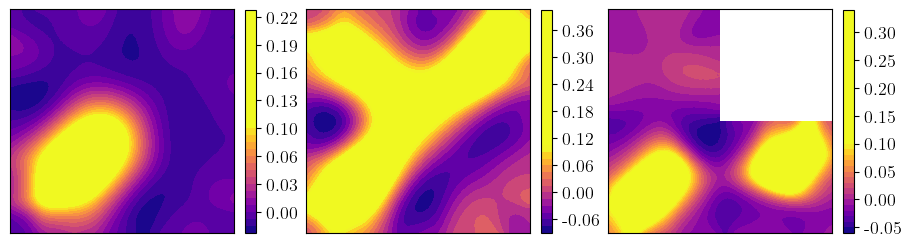

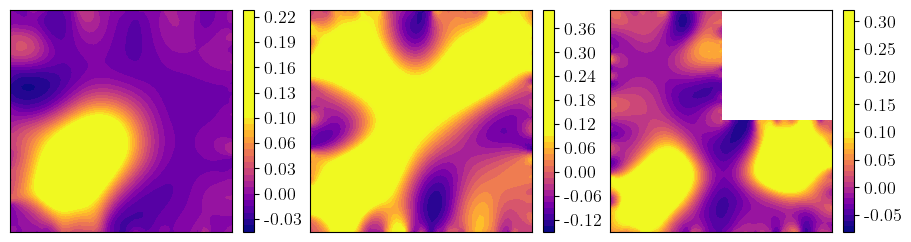

In [90]:
f_list = []
for fs in f_dict.values():
    f_list.extend(fs)

from utils.colors import CMAP
from utils.plotting import save_plot

def plot_multiple_f(f_list, names=None, fig_name=None, shrink=0.3):
    fig, axes = plt.subplots(1, 3, figsize=(9, 6.06), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP, vmin=vmin, vmax=0.1)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

    #axes[0][0].set_ylabel('rSVD $K$')
    #axes[1][0].set_ylabel('rSVD $K^*$')
    #axes[1][0].set_xlabel('Problem I')
    #axes[1][1].set_xlabel('Problem II')
    #axes[1][2].set_xlabel('Problem III')
    save_plot(fig_name=fig_name)
    plt.show()

plot_multiple_f(f_list1, fig_name='clipped_solution_K', shrink=0.373)
plot_multiple_f(f_list2, fig_name='clipped_solution_K_star', shrink=0.370)